In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
np.random.seed(42)

df = pd.DataFrame({
    "Student_ID": range(1001,2001),
    "Attendance": np.random.randint(50,101,1000),
    "Assignment": np.random.randint(40,101,1000),
    "Study_Hours": np.random.randint(1,11,1000),
    "Participation": np.random.randint(1,11,1000)
})

df["Exam_Score"] = (
    0.30*df["Attendance"] +
    0.35*df["Assignment"] +
    2.5*df["Study_Hours"] +
    1.5*df["Participation"] +
    np.random.randint(-10,11,1000)
)

df["Exam_Score"] = df["Exam_Score"].clip(35,100).round().astype(int)

df.head()

,Student_ID,Attendance,Assignment,Study_Hours,Participation,Exam_Score
0,1001,88,80,9,3,85
1,1002,78,84,1,1,55
2,1003,64,57,8,6,71
3,1004,92,86,2,6,79
4,1005,57,75,8,1,71


In [3]:
def performance(score):
    if score >= 85:
        return "High"
    elif score >= 70:
        return "Medium"
    else:
        return "Low"

df["Performance"] = df["Exam_Score"].apply(performance)

df.head()

,Student_ID,Attendance,Assignment,Study_Hours,Participation,Exam_Score,Performance
0,1001,88,80,9,3,85,High
1,1002,78,84,1,1,55,Low
2,1003,64,57,8,6,71,Medium
3,1004,92,86,2,6,79,Medium
4,1005,57,75,8,1,71,Medium


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Student_ID     1000 non-null   int64 
 1   Attendance     1000 non-null   int64 
 2   Assignment     1000 non-null   int64 
 3   Study_Hours    1000 non-null   int64 
 4   Participation  1000 non-null   int64 
 5   Exam_Score     1000 non-null   int64 
 6   Performance    1000 non-null   object
dtypes: int64(6), object(1)
memory usage: 54.8+ KB


In [5]:
df.isnull().sum()

,0
Student_ID,0
Attendance,0
Assignment,0
Study_Hours,0
Participation,0
Exam_Score,0
Performance,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,Student_ID,Attendance,Assignment,Study_Hours,Participation,Exam_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1500.500000,75.232000,70.383000,5.425000,5.447000,69.124000
std,288.819436,14.651513,17.403655,2.846837,2.835354,12.302194
min,1001.000000,50.000000,40.000000,1.000000,1.000000,35.000000
25%,1250.750000,63.000000,56.000000,3.000000,3.000000,61.000000
50%,1500.500000,75.000000,71.000000,5.000000,5.000000,69.000000
75%,1750.250000,87.000000,85.000000,8.000000,8.000000,78.000000
max,2000.000000,100.000000,100.000000,10.000000,10.000000,100.000000


In [8]:
analysis = df.groupby("Performance").mean(numeric_only=True)

print(analysis)

              Student_ID  Attendance  Assignment  Study_Hours  Participation  \
Performance                                                                    
High         1542.571429   83.526786   85.437500     7.866071       6.758929   
Low          1487.121857   71.526112   63.524178     4.255319       4.794971   
Medium       1506.442049   77.892183   75.396226     6.318059       5.959569   

             Exam_Score  
Performance              
High          90.232143  
Low           59.516441  
Medium        76.140162  


In [9]:
at_risk = df[
    (df["Attendance"] < 70) |
    (df["Exam_Score"] < 60)
]

print(at_risk)

     Student_ID  Attendance  Assignment  Study_Hours  Participation  \
1          1002          78          84            1              1   
2          1003          64          57            8              6   
4          1005          57          75            8              1   
7          1008          68          73            3              3   
9          1010          60          47           10              3   
..          ...         ...         ...          ...            ...   
994        1995          62          41           10              1   
995        1996          69          71            5              1   
997        1998          53          85            4              6   
998        1999          59          66           10              8   
999        2000          52          88            2              6   

     Exam_Score Performance  
1            55         Low  
2            71      Medium  
4            71      Medium  
7            67         Low

In [10]:
print("Total At-Risk Students :", len(at_risk))

Total At-Risk Students : 456


In [11]:
X = df[[
    "Attendance",
    "Assignment",
    "Study_Hours",
    "Participation"
]]

y = df["Performance"]

In [12]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [13]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [14]:
y_pred = model.predict(X_test)

In [15]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy :",accuracy)

Accuracy : 0.59


In [16]:
cm = confusion_matrix(y_test,y_pred)

print(cm)

[[ 8  0  9]
 [ 2 78 37]
 [ 7 27 32]]


In [17]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

        High       0.47      0.47      0.47        17
         Low       0.74      0.67      0.70       117
      Medium       0.41      0.48      0.44        66

    accuracy                           0.59       200
   macro avg       0.54      0.54      0.54       200
weighted avg       0.61      0.59      0.60       200



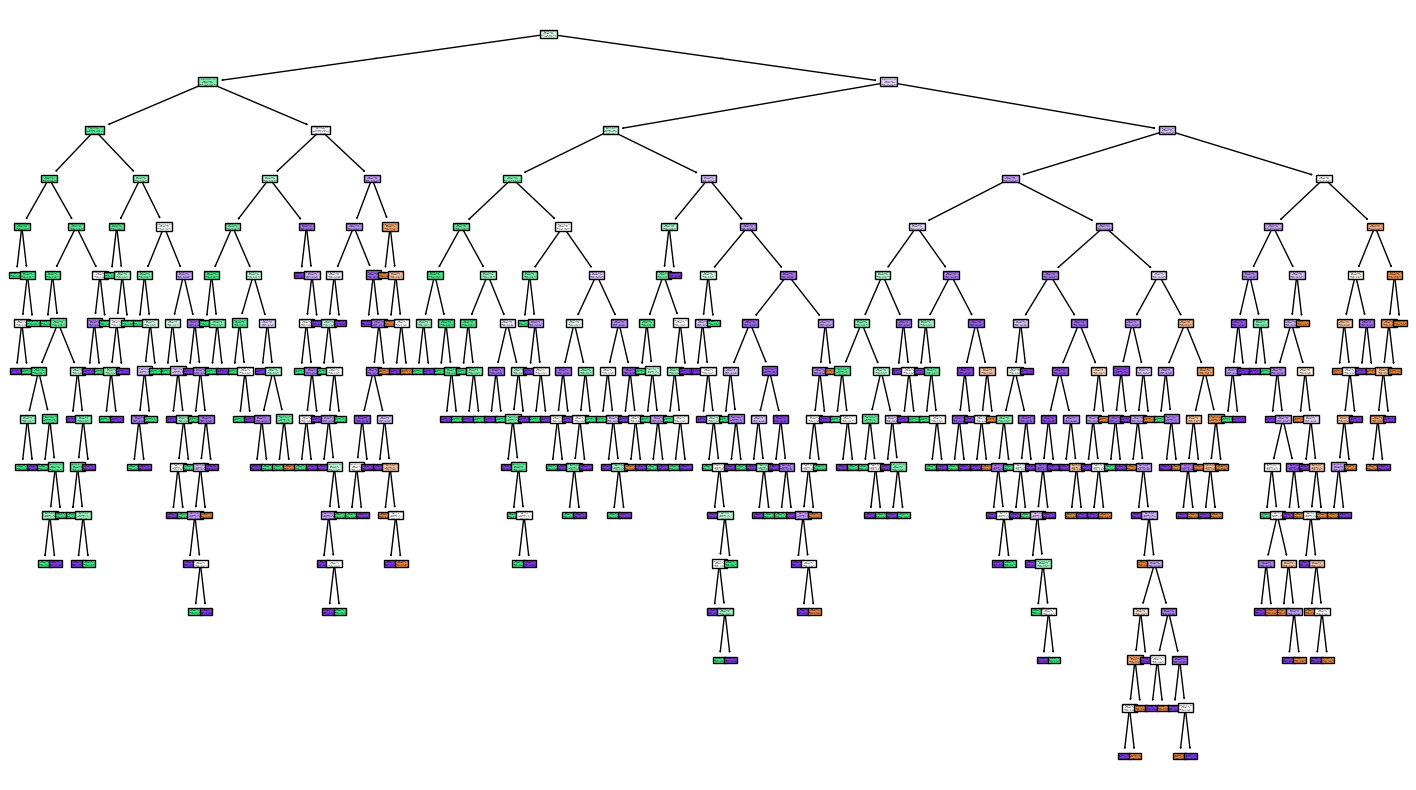

In [18]:
plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True
)

plt.show()